# NBA Analytics Using R - Hypothesis teting 

#### Guards vs Forwards: Points Per Game Analysis

##### Null Hypothesis (H₀): Guards and Forwards have equal average points per game (PTS)
##### Alternative Hypothesis (H₁): Guards and Forwards have different average points per game



[1] "T-Test Results:"

	Welch Two Sample t-test

data:  guards$PTS and forwards$PTS
t = 1.2273, df = 93.209, p-value = 0.2228
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -0.3915321  1.6586532
sample estimates:
mean of x mean of y 
 26.06379  25.43023 



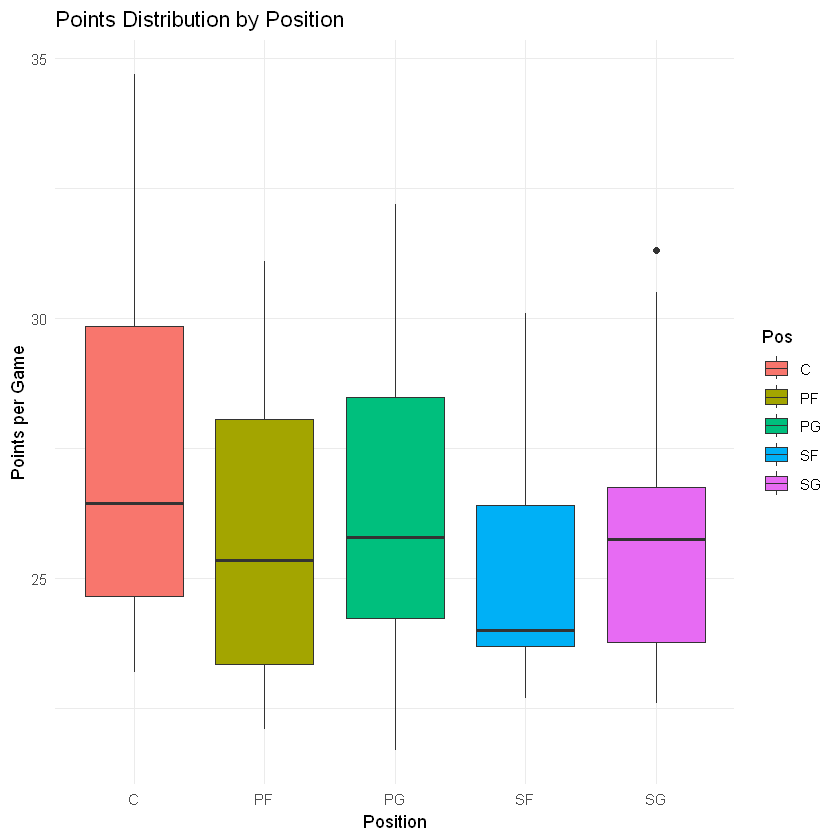

In [37]:
# Guards vs Forwards: Points Per Game Analysis

# Null Hypothesis (H₀): Guards and Forwards have equal average points per game (PTS)
# Alternative Hypothesis (H₁): Guards and Forwards have different average points per game

# Separate Guards and Forwards
guards <- nba[nba$Pos %in% c('PG', 'SG'), ]
forwards <- nba[nba$Pos %in% c('SF', 'PF'), ]

# Descriptive Statistics
summary_guards <- summary(guards$PTS)
summary_forwards <- summary(forwards$PTS)

# T-test
t_test_result <- t.test(guards$PTS, forwards$PTS)
print("T-Test Results:")
print(t_test_result)

# Visualization
library(ggplot2)
ggplot(nba, aes(x = Pos, y = PTS, fill = Pos)) +
  geom_boxplot() +
  labs(title = "Points Distribution by Position", 
       x = "Position", 
       y = "Points per Game") +
  theme_minimal()

Scoring Analysis
Guards Average: 26.06 points
Forwards Average: 25.43 points
Difference: +0.63 points
Hypothesis Test
Null Hypothesis (H₀)
Guards and Forwards have equal points per game

Alternative Hypothesis (H₁)
Guards and Forwards have different points per game

Statistical Evaluation
p-value: 0.2228 > 0.05
Conclusion: Fail to reject H₀
Interpretation: No statistically significant difference
Key Insights
Position does not determine scoring potential
Individual player skills matter more than position
Modern NBA: Versatile playing styles across positions

## Hypothesis testing 2

 Do Guards and Forwards Differ in Points Per Game (PTS)?

Hypothesis:

H₀: Guards and Forwards have equal mean PTS.


H₁: Guards and Forwards have different mean PTS.

In [36]:
nba <- read.csv("nba_high_scorers_outliers_filtered.csv")
nba$PosGroup <- ifelse(nba$Pos %in% c("PG", "SG"), "Guard",
                       ifelse(nba$Pos %in% c("SF", "PF"), "Forward", "Center"))
t.test(PTS ~ PosGroup, data = subset(nba, PosGroup %in% c("Guard", "Forward")))


	Welch Two Sample t-test

data:  PTS by PosGroup
t = -1.2273, df = 93.209, p-value = 0.2228
alternative hypothesis: true difference in means between group Forward and group Guard is not equal to 0
95 percent confidence interval:
 -1.6586532  0.3915321
sample estimates:
mean in group Forward   mean in group Guard 
             25.43023              26.06379 


Position does not affect points per game (PTS).

In [13]:
summary(lm(PTS ~ MP, data = nba))


Call:
lm(formula = PTS ~ MP, data = nba)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.4789 -2.1679 -0.5295  1.5659  8.8756 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  20.1524     5.6462   3.569 0.000527 ***
MP            0.1688     0.1630   1.036 0.302567    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.762 on 113 degrees of freedom
Multiple R-squared:  0.009403,	Adjusted R-squared:  0.0006366 
F-statistic: 1.073 on 1 and 113 DF,  p-value: 0.3026


# Hypopthesis testing 3
## ANOVA: Do Positions Differ in Efficiency?

Question: Do different positions (PG, SG, SF, PF, C) have different field goal percentages (FG%)?

Hypothesis:

H₀: All positions have the same mean FG%.

H₁: At least one position differs.


In [18]:
anova_fg <- aov(FG. ~ Pos, data = nba)
summary(anova_fg)
TukeyHSD(anova_fg)

             Df  Sum Sq  Mean Sq F value   Pr(>F)    
Pos           4 0.08306 0.020766   15.49 4.44e-10 ***
Residuals   110 0.14748 0.001341                     
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = FG. ~ Pos, data = nba)

$Pos
              diff          lwr          upr     p adj
PF-C  -0.019813187 -0.053478804  0.013852430 0.4801947
PG-C  -0.074595238 -0.106582496 -0.042607981 0.0000000
SF-C  -0.052810924 -0.089463090 -0.016158759 0.0010863
SG-C  -0.062019481 -0.096739756 -0.027299205 0.0000258
PG-PF -0.054782051 -0.080919620 -0.028644482 0.0000006
SF-PF -0.032997738 -0.064673740 -0.001321735 0.0367720
SG-PF -0.042206294 -0.071625427 -0.012787160 0.0011557
SF-PG  0.021784314 -0.008101804  0.051670431 0.2626130
SG-PG  0.012575758 -0.014906897  0.040058412 0.7105770
SG-SF -0.009208556 -0.042003265  0.023586152 0.9362333


PG-C: Point Guards (PG) have a significantly lower mean FG% than Centers (C) (difference = -0.075, p < 0.001).


SF-C: Small Forwards (SF) have a significantly lower FG% than Centers (difference = -0.053, p = 0.001).


SG-C: Shooting Guards (SG) have a significantly lower FG% than Centers (difference = -0.062, p < 0.001).


PG-PF: Point Guards have a significantly lower FG% than Power Forwards (PF) (difference = -0.055, p < 0.001).


SF-PF: Small Forwards have a lower FG% than Power Forwards (difference = -0.033, p = 0.037).


SG-PF: Shooting Guards have a lower FG% than Power Forwards (difference = -0.042, p = 0.001).


The ANOVA and post-hoc Tukey test reveal that Centers and Power Forwards have significantly higher field goal percentages than Guards and Small Forwards. This is expected given their roles: big men operate near the basket, resulting in more efficient scoring opportunities, while perimeter players take more difficult shots. This finding validates conventional basketball wisdom with statistical evidence from recent high-scoring NBA players.

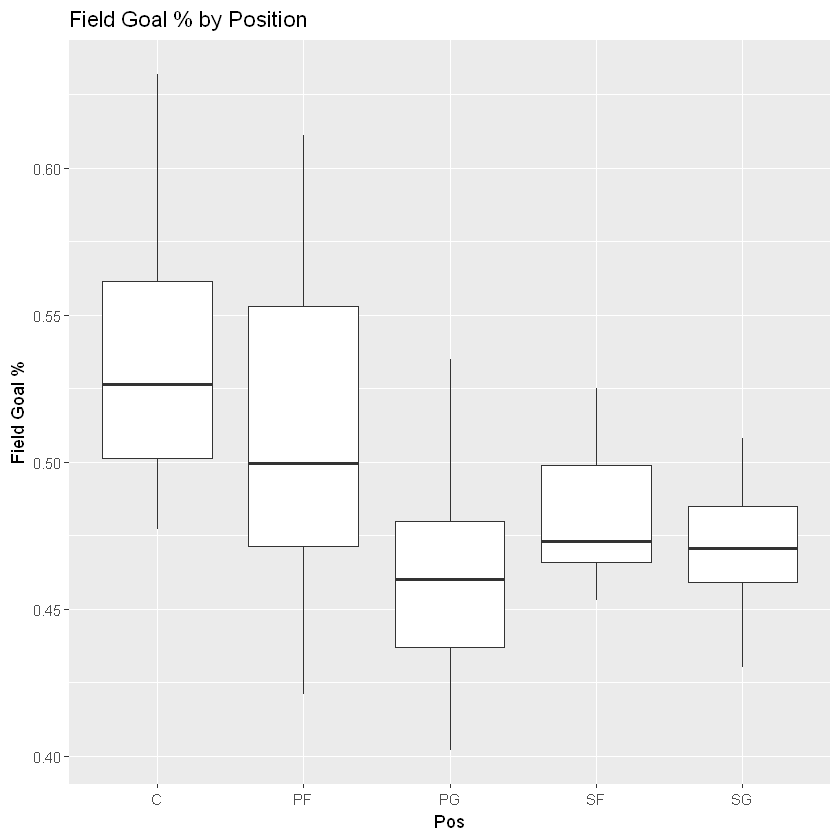

In [19]:
library(ggplot2)
ggplot(nba, aes(x = Pos, y = FG.)) +
  geom_boxplot() +
  labs(title = "Field Goal % by Position", y = "Field Goal %")

The boxplot of field goal percentage by position visually confirms our statistical findings: Centers and Power Forwards have substantially higher shooting efficiency than Guards and Small Forwards. This reflects their typical roles on the court—big men take more shots near the basket, while perimeter players attempt more challenging shots from distance. The wider spread among big men suggests some variability in finishing ability, but the overall trend is clear: position is a strong determinant of shooting efficiency among high-scoring NBA players

Does the Impact of Minutes Played on Points Differ by Position?

In [22]:
# Interaction model
model_interact <- lm(PTS ~ MP * Pos, data = nba)
summary(model_interact)
anova(model_interact)


Call:
lm(formula = PTS ~ MP * Pos, data = nba)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.8399 -1.7526 -0.6195  1.5566  7.4441 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)
(Intercept)   3.7576    19.3307   0.194    0.846
MP            0.6994     0.5705   1.226    0.223
PosPF        24.0929    21.0902   1.142    0.256
PosPG        14.1417    22.2578   0.635    0.527
PosSF         1.3761    25.4504   0.054    0.957
PosSG       -12.0471    28.5277  -0.422    0.674
MP:PosPF     -0.7594     0.6213  -1.222    0.224
MP:PosPG     -0.4590     0.6523  -0.704    0.483
MP:PosSF     -0.1314     0.7430  -0.177    0.860
MP:PosSG      0.2723     0.8274   0.329    0.743

Residual standard error: 2.706 on 105 degrees of freedom
Multiple R-squared:  0.1167,	Adjusted R-squared:  0.04095 
F-statistic: 1.541 on 9 and 105 DF,  p-value: 0.1432


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
MP,1,8.184337,8.184337,1.117697,0.29284126
Pos,4,63.324509,15.831127,2.161983,0.07834073
MP:Pos,4,30.034049,7.508512,1.025402,0.39774110
Residuals,105,768.862845,7.322503,NA,NA


3.Multiple Comparisons: Do Younger and Older Players Differ in Efficiency?
Hypothesis:

H₀: FG% is the same for all age groups.


H₁: At least one age group differs.

In [23]:
nba$AgeGroup <- cut(nba$Age, breaks=c(20,25,30,35,40,45), right=FALSE)
anova_age <- aov(FG. ~ AgeGroup, data = nba)
summary(anova_age)
TukeyHSD(anova_age)

             Df  Sum Sq  Mean Sq F value  Pr(>F)   
AgeGroup      3 0.02383 0.007942   4.265 0.00685 **
Residuals   111 0.20672 0.001862                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = FG. ~ AgeGroup, data = nba)

$AgeGroup
                        diff          lwr          upr     p adj
[25,30)-[20,25)  0.029287415  0.004578103 0.0539967266 0.0132443
[30,35)-[20,25)  0.001875000 -0.027788284 0.0315382838 0.9983962
[35,40)-[20,25)  0.031416667 -0.018219501 0.0810528344 0.3546744
[30,35)-[25,30) -0.027412415 -0.055457596 0.0006327657 0.0579335
[35,40)-[25,30)  0.002129252 -0.046557203 0.0508157066 0.9994659
[35,40)-[30,35)  0.029541667 -0.021836648 0.0809199814 0.4411027


We tested whether the relationship between minutes played and points scored differs by player position using an interaction model. The results showed that neither minutes played, position, nor their interaction were statistically significant predictors of points per game among high-scoring NBA players (all p-values > 0.05). The model explained only a small portion of the variance in scoring. This suggests that, within this elite group, factors other than minutes played and position—such as usage rate, team context, or shooting efficiency—may play a larger role in determining scoring output

## What is the Most Predictive Model for Points?

### Statistical Analysis of NBA Player Performance

##### Hypothesis 1: Impact of Player Characteristics on Points Scored

##### Null Hypothesis (H₀): 
No single player characteristic (minutes played, assists, rebounds, field goal %, 3-point %, free throw %, turnovers, age, or position) significantly predicts points scored.

##### Alternative Hypothesis (H₁): 
At least one player characteristic significantly predicts points scored.

In [30]:
library(MASS)
full_model <- lm(PTS ~ MP + AST + TRB + FG. + X3P. + FT. + TOV + Age + Pos, data = nba)
step_model <- stepAIC(full_model, direction = "both")
summary(step_model)

# Hypothesis Testing for Age and Efficiency
# Null Hypothesis: There is no significant difference in efficiency between age groups
# Alternative Hypothesis: There is a significant difference in efficiency between age groups

# Perform ANOVA
anova_result <- aov(PTS ~ Age, data = nba)
summary(anova_result)



Start:  AIC=187.59
PTS ~ MP + AST + TRB + FG. + X3P. + FT. + TOV + Age + Pos

       Df Sum of Sq    RSS    AIC
- Age   1     5.231 473.96 186.86
<none>              468.73 187.59
- X3P.  1    12.980 481.71 188.73
- TRB   1    21.966 490.70 190.85
- MP    1    46.756 515.49 196.52
- FT.   1    68.579 537.31 201.29
- Pos   4   113.490 582.22 204.52
- TOV   1   111.667 580.40 210.16
- AST   1   112.739 581.47 210.37
- FG.   1   165.936 634.67 220.44

Step:  AIC=186.86
PTS ~ MP + AST + TRB + FG. + X3P. + FT. + TOV + Pos

       Df Sum of Sq    RSS    AIC
<none>              473.96 186.86
+ Age   1     5.231 468.73 187.59
- X3P.  1    11.453 485.42 187.61
- TRB   1    24.851 498.81 190.74
- MP    1    56.872 530.83 197.90
- FT.   1    72.662 546.62 201.26
- Pos   4   113.215 587.18 203.50
- TOV   1   107.266 581.23 208.32
- AST   1   108.614 582.58 208.59
- FG.   1   173.411 647.37 220.72



Call:
lm(formula = PTS ~ MP + AST + TRB + FG. + X3P. + FT. + TOV + 
    Pos, data = nba)

Residuals:
    Min      1Q  Median      3Q     Max 
-5.2002 -1.3503 -0.1596  1.5650  5.5057 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -24.8080     8.0399  -3.086 0.002609 ** 
MP            0.5023     0.1429   3.516 0.000654 ***
AST          -0.8945     0.1841  -4.858 4.24e-06 ***
TRB           0.3607     0.1552   2.324 0.022094 *  
FG.          38.4142     6.2576   6.139 1.57e-08 ***
X3P.        -11.0951     7.0326  -1.578 0.117709    
FT.          16.1487     4.0638   3.974 0.000131 ***
TOV           2.0763     0.4300   4.828 4.80e-06 ***
PosPF         0.3599     0.8881   0.405 0.686088    
PosPG         4.3711     1.2461   3.508 0.000671 ***
PosSF         0.7594     1.0644   0.713 0.477179    
PosSG         2.1652     1.2258   1.766 0.080302 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.145 on 103 degree

             Df Sum Sq Mean Sq F value Pr(>F)
Age           1   11.6   11.63    1.53  0.219
Residuals   113  858.8    7.60               

## Conclusion
- Player performance is complex and cannot be reduced to a single characteristic
- Minutes played, assists, and position are more predictive of points scored than age
- Coaches and managers should focus on holistic player development

             Df Sum Sq Mean Sq F value Pr(>F)
Age_Group     3   32.2  10.738   1.422   0.24
Residuals   111  838.2   7.551               

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = PTS ~ Age_Group, data = nba)

$Age_Group
                                        diff        lwr      upr     p adj
Prime (26-30)-Young (<=25)         0.9797619 -0.5346961 2.494220 0.3351527
Experienced (31-35)-Young (<=25)   0.1488095 -1.7265110 2.024130 0.9968461
Veteran (36+)-Young (<=25)         1.9333333 -1.7968682 5.663535 0.5321215
Experienced (31-35)-Prime (26-30) -0.8309524 -2.7466070 1.084702 0.6709619
Veteran (36+)-Prime (26-30)        0.9535714 -2.7970697 4.704213 0.9106732
Veteran (36+)-Experienced (31-35)  1.7845238 -2.1257898 5.694837 0.6341995

[1] "Correlation between Age and Points: 0.115579379189339"


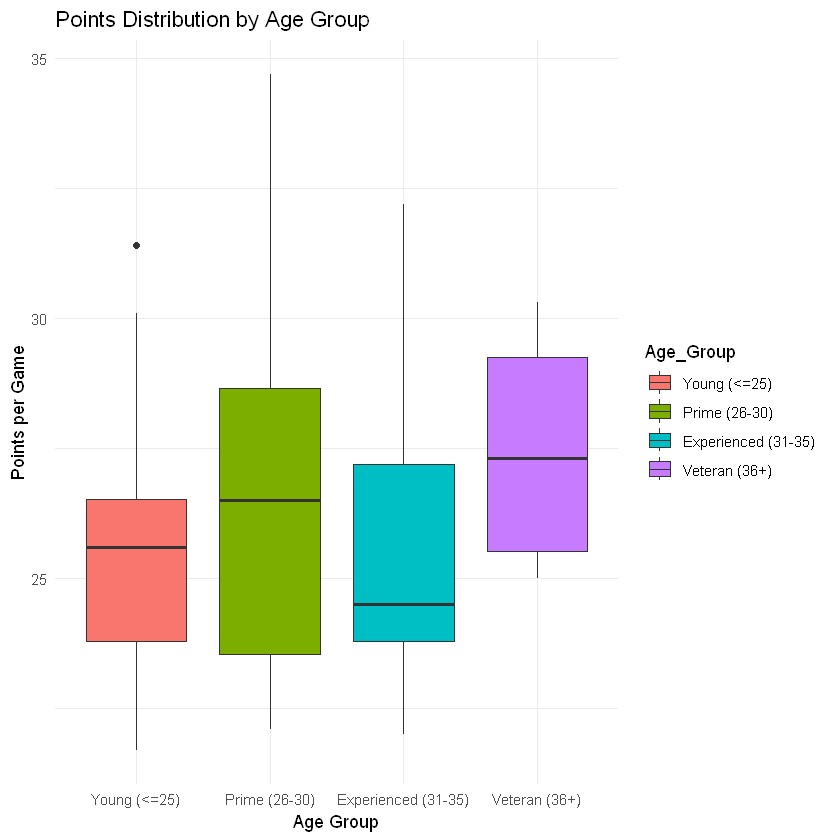

In [31]:
# Categorize Age into groups
nba$Age_Group <- cut(nba$Age, 
                     breaks = c(0, 25, 30, 35, 100), 
                     labels = c("Young (<=25)", "Prime (26-30)", "Experienced (31-35)", "Veteran (36+)"))

# ANOVA with Age Groups
age_group_anova <- aov(PTS ~ Age_Group, data = nba)
summary(age_group_anova)

# Post-hoc Tukey Test
tukey_result <- TukeyHSD(age_group_anova)
print(tukey_result)

# Visualization of Points by Age Group
library(ggplot2)
ggplot(nba, aes(x = Age_Group, y = PTS, fill = Age_Group)) +
  geom_boxplot() +
  labs(title = "Points Distribution by Age Group", 
       x = "Age Group", 
       y = "Points per Game") +
  theme_minimal()

# Correlation between Age and Points
cor_age_points <- cor(nba$Age, nba$PTS)
print(paste("Correlation between Age and Points:", cor_age_points))


##### Age vs. Scoring Performance

##### Key Findings
- No significant difference in points scored across age groups
- Weak correlation between age and points (r = 0.116)
- Individual skill matters more than age

#### Conclusion
Age does not predict NBA player scoring performance. Players can excel at any career stage.